### Set Up

In [1]:
import os
os.environ["KERAS_BACKEND"] = "torch"

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras
import tensorflow as tf
import kagglehub
import torch
import zipfile
import os, shutil, pathlib

In [3]:
# Quick health check to prove it works:
print("Is PyTorch utilizing the GPU?:", torch.cuda.is_available())
print("Device Name:", torch.cuda.get_device_name(0))

Is PyTorch utilizing the GPU?: True
Device Name: NVIDIA GeForce RTX 5050 Laptop GPU


### Load dataset

In [4]:
fpath = keras.utils.get_file(origin="https://www.robots.ox.ac.uk/~vgg/data/flowers/102/102flowers.tgz", extract=True)
fpath

'C:\\Users\\PRASHANTH N\\.keras\\datasets\\102flowers.tgz'

In [5]:
batch_size = 32
image_size = 128

images_dir = os.path.join(fpath, "jpg")
dataset = keras.utils.image_dataset_from_directory(images_dir, labels=None, image_size=(image_size, image_size), crop_to_aspect_ratio=True)
dataset = dataset.rebatch( batch_size, drop_remainder=True)

Found 8189 files.


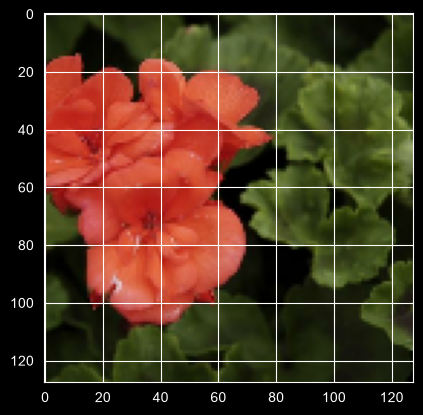

In [6]:
for batch in dataset:
    img = batch.numpy()[0]
    break
plt.imshow(img.astype("uint8"))

### Model

In [7]:
def residual_block(x, width):
    input_width = x.shape[3]
    if input_width == width:
        residual = x
    else:
        residual = keras.layers.Conv2D(width, 1)(x)
    x = keras.layers.BatchNormalization(center=False, scale=False)(x)
    x = keras.layers.Conv2D(width, 3, padding="same", activation="swish")(x)
    x = keras.layers.Conv2D(width, 3, padding="same")(x)
    x = x + residual
    return x


def get_model(image_size, widths, block_depth):
    noisy_images = keras.Input(shape=(image_size, image_size, 3))
    noise_rates = keras.Input(shape=(1, 1, 1))
    x = keras.layers.Conv2D(widths[0], 1)(noisy_images)
    n = keras.layers.UpSampling2D(image_size, interpolation="nearest")(noise_rates)
    x = keras.layers.Concatenate()([x, n])
    skips = []
    for width in widths[:-1]:
        for _ in range(block_depth):
            x = residual_block(x, width)
            skips.append(x)
        x = keras.layers.AveragePooling2D(pool_size=2)(x)
    for _ in range(block_depth):
        x = residual_block(x, widths[-1])
    for width in reversed(widths[:-1]):
        x = keras.layers.UpSampling2D(size=2, interpolation="bilinear")(x)
        for _ in range(block_depth):
            x = keras.layers.Concatenate()([x, skips.pop()])
            x = residual_block(x, width)
    pred_noise_masks = keras.layers.Conv2D(3, 1, kernel_initializer="zeros")(x)
    return keras.Model([noisy_images, noise_rates], pred_noise_masks)

In [8]:
def diffusion_schedule(diffusion_times, min_signal_rate=0.02, max_signal_rate=0.95):
    start_angle = keras.ops.cast(keras.ops.arccos(max_signal_rate), "float32")
    end_angle = keras.ops.cast(keras.ops.arccos(min_signal_rate), "float32")
    diffusion_angles = start_angle + diffusion_times * (end_angle - start_angle)
    signal_rates = keras.ops.cos(diffusion_angles)
    noise_rates = keras.ops.sin(diffusion_angles)
    return noise_rates, signal_rates

In [9]:
# Custom Model
class DiffusionModel(keras.Model):
    def __init__(self, image_size, widths, block_depth, **kwargs):
        super().__init__(**kwargs)
        self.image_size = image_size
        self.denoising_model = get_model(image_size, widths, block_depth)
        self.seed_generator = keras.random.SeedGenerator()
        self.loss = keras.losses.MeanAbsoluteError()
        self.normalizer = keras.layers.Normalization()


    def denoise(self, noisy_images, noise_rates, signal_rates):
        pred_noise_masks = self.denoising_model([noisy_images, noise_rates])
        pred_images = (noisy_images - noise_rates * pred_noise_masks) / signal_rates
        return pred_images, pred_noise_masks


    def call(self, images):
        images = self.normalizer(images)
        noise_masks = keras.random.normal((batch_size, self.image_size, self.image_size, 3), seed=self.seed_generator)
        diffusion_times = keras.random.uniform((batch_size, 1, 1, 1), minval=0.0, maxval=1.0, seed=self.seed_generator)
        noise_rates, signal_rates = diffusion_schedule(diffusion_times)
        noisy_images = signal_rates * images + noise_rates * noise_masks
        pred_images, pred_noise_masks = self.denoise(noisy_images, noise_rates, signal_rates)
        return pred_images, pred_noise_masks, noise_masks


    def compute_loss(self, x, y, y_pred, sample_weight=None, training=True):
        _, pred_noise_masks, noise_masks = y_pred
        return self.loss(noise_masks, pred_noise_masks)


    def generate(self, num_images, diffusion_steps):
        noisy_images = keras.random.normal((num_images, self.image_size, self.image_size, 3), seed=self.seed_generator)
        step_size = 1.0 / diffusion_steps
        pred_images = None
        for step in range(diffusion_steps):
            diffusion_times = keras.ops.ones((num_images, 1, 1, 1)) - step * step_size
            noise_rates, signal_rates = diffusion_schedule(diffusion_times)
            pred_images, pred_noises = self.denoise(noisy_images, noise_rates, signal_rates)
            next_diffusion_times = diffusion_times - step_size
            next_noise_rates, next_signal_rates = diffusion_schedule(next_diffusion_times)
            noisy_images = (next_signal_rates * pred_images + next_noise_rates * pred_noises)
        images = (self.normalizer.mean + pred_images * self.normalizer.variance**0.5)
        return keras.ops.clip(images, 0.0, 255.0)

### callbacks

In [10]:
class VisualizationCallback(keras.callbacks.Callback):
    def __init__(self, diffusion_steps=20, num_rows=3, num_cols=6):
        self.diffusion_steps = diffusion_steps
        self.num_rows = num_rows
        self.num_cols = num_cols


    def on_epoch_end(self, epoch=None, logs=None):
        generated_images = self.model.generate(num_images=self.num_rows * self.num_cols, diffusion_steps=self.diffusion_steps)
        plt.figure(figsize=(self.num_cols * 2.0, self.num_rows * 2.0))
        for row in range(self.num_rows):
            for col in range(self.num_cols):
                i = row * self.num_cols + col
                plt.subplot(self.num_rows, self.num_cols, i + 1)
                img = keras.ops.convert_to_numpy(generated_images[i]).astype("uint8")
                plt.imshow(img)
                plt.axis("off")
        plt.tight_layout()
        plt.show()
        plt.close()

### Training

In [11]:
model = DiffusionModel(image_size, widths=[32, 64, 96, 128], block_depth=2)
model.normalizer.adapt(dataset)

In [12]:
model.compile(optimizer=keras.optimizers.AdamW(learning_rate=keras.optimizers.schedules.InverseTimeDecay(initial_learning_rate=1e-3,                  decay_steps=1000, decay_rate=0.1), use_ema=True, ema_overwrite_frequency=100))

C:\Users\PRASHANTH N\PycharmProjects\MTechSem2\gpu\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


Epoch 1/2
    255/Unknown 2291s 9s/step - loss: 0.2789

C:\Users\PRASHANTH N\PycharmProjects\MTechSem2\gpu\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


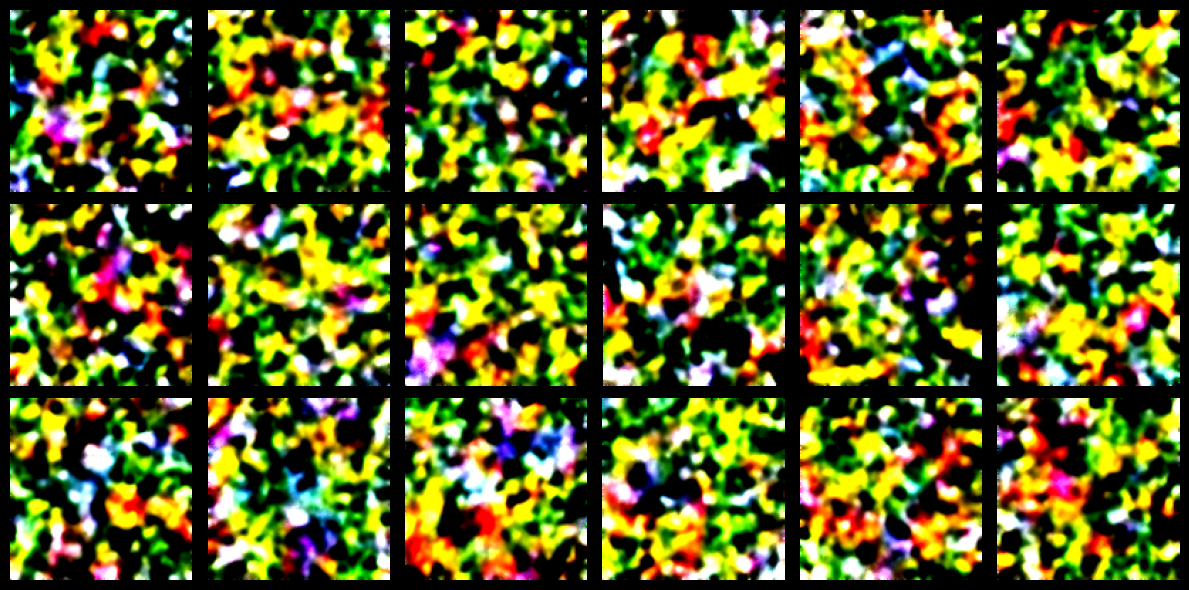

C:\Users\PRASHANTH N\PycharmProjects\MTechSem2\gpu\.venv\Lib\site-packages\keras\src\callbacks\model_checkpoint.py:329: UserWarning: Can save best model only with val_loss available.
  if self._should_save_model(epoch, batch, logs, filepath):


255/255 ━━━━━━━━━━━━━━━━━━━━ 2323s 9s/step - loss: 0.2789
Epoch 2/2
114/255 ━━━━━━━━━━━━━━━━━━━━ 20:14 9s/step - loss: 0.1914

In [ ]:
model.fit(dataset, epochs=2, callbacks=[VisualizationCallback(),
          keras.callbacks.ModelCheckpoint(filepath="diffusion_model.weights.h5",save_weights_only=True, save_best_only=True)])